#English-to-Indonesian Neural Machine Translation
### Using the Transformer Architecture and Beam Search


# 0. Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# %mkdir /content/drive/MyDrive/Transformer

In [3]:
%cd /content/drive/MyDrive/transformer

/content/drive/MyDrive/transformer


In [4]:
!pwd

/content/drive/MyDrive/transformer


In [5]:
!pip install torch torchvision datasets tokenizers matplotlib seaborn -q

# 1. Imports

In [6]:
import numpy as np
import torch
import math
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from torch import nn
import torch.nn.functional as F
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

# 2. Dataset

Dataset: Helsinki-NLP/opus-100 (en-id)   

In [ ]:
from datasets import load_dataset

MAX_SAMPLES = 50_000
MAX_SEQ_LEN = 50       # max tokens per sentence

raw = load_dataset("Helsinki-NLP/opus-100", "en-id", split="train")
raw = raw.select(range(min(MAX_SAMPLES, len(raw))))

en_sentences = [ex['translation']['en'] for ex in raw]
id_sentences = [ex['translation']['id'] for ex in raw]

print(f"Loaded {len(en_sentences):,} sentence pairs.")
print("Example EN:", en_sentences[0])
print("Example ID:", id_sentences[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-id/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

en-id/train-00000-of-00001.parquet:   0%|          | 0.00/57.4M [00:00<?, ?B/s]

en-id/validation-00000-of-00001.parquet:   0%|          | 0.00/132k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loaded 50,000 sentence pairs.
Example EN: Hmm. _
Example ID: Hmm.


# 3. BPE Tokenizer


In [ ]:
VOCAB_SIZE = 16_000   # shared bpe vocabulary
START_TOKEN = "[START]"
END_TOKEN   = "[END]"
PAD_TOKEN   = "[PAD]"
UNK_TOKEN   = "[UNK]"

# train a shared bpe tokenizer on both languages
tokenizer = Tokenizer(BPE(unk_token=UNK_TOKEN))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=[PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN],
    min_frequency=2,
)

# feed both languages together
all_sentences = en_sentences + id_sentences
tokenizer.train_from_iterator(all_sentences, trainer=trainer)

# add [START] / [END] post-processing
tokenizer.post_processor = TemplateProcessing(
    single=f"{START_TOKEN} $A {END_TOKEN}",
    special_tokens=[
        (START_TOKEN, tokenizer.token_to_id(START_TOKEN)),
        (END_TOKEN,   tokenizer.token_to_id(END_TOKEN)),
    ],
)

tokenizer.enable_padding(
    pad_id=tokenizer.token_to_id(PAD_TOKEN),
    pad_token=PAD_TOKEN,
    length=MAX_SEQ_LEN,
)
tokenizer.enable_truncation(max_length=MAX_SEQ_LEN)

ACTUAL_VOCAB_SIZE = tokenizer.get_vocab_size()
PAD_ID   = tokenizer.token_to_id(PAD_TOKEN)
START_ID = tokenizer.token_to_id(START_TOKEN)
END_ID   = tokenizer.token_to_id(END_TOKEN)

print(f"vocab size: {ACTUAL_VOCAB_SIZE}")
print(f"PAD={PAD_ID}, START={START_ID}, END={END_ID}")

enc = tokenizer.encode("hello world")
print("Tokens:", enc.tokens)
print("IDs:   ", enc.ids)

Vocab size: 16000
PAD=0, START=2, END=3
Tokens: ['[START]', 'hello', 'world', '[END]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
IDs:    [2, 5918, 1248, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# 4. Dataset & DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, tokenizer, max_len):
        self.src = src_sentences
        self.tgt = tgt_sentences
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        src_enc = self.tokenizer.encode(self.src[idx])
        tgt_enc = self.tokenizer.encode(self.tgt[idx])
        return (
            torch.tensor(src_enc.ids, dtype=torch.long),
            torch.tensor(tgt_enc.ids, dtype=torch.long),
        )

TRAIN_SPLIT = int(0.95 * len(en_sentences))
train_ds = TranslationDataset(en_sentences[:TRAIN_SPLIT], id_sentences[:TRAIN_SPLIT], tokenizer, MAX_SEQ_LEN)
val_ds   = TranslationDataset(en_sentences[TRAIN_SPLIT:], id_sentences[TRAIN_SPLIT:], tokenizer, MAX_SEQ_LEN)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 742 | Val batches: 40


# 5. Transformer Architecture

## Helpers

In [ ]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = q.size()[-1]
    scaled = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(d_k)  # (B, H, T_q, T_k)
    if mask is not None:
        # mask shape (B, 1, ?, T_k) broadcasts over H automatically
        scaled = scaled + mask
    attention = F.softmax(scaled, dim=-1)   # (B, H, T_q, T_k)
    values = torch.matmul(attention, v)     # (B, H, T_q, d_k)
    return values, attention

## Positional Encoding

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_sequence_length):
        super().__init__()
        self.max_sequence_length = max_sequence_length
        self.d_model = d_model

    def forward(self):
        even_i       = torch.arange(0, self.d_model, 2).float() #list of number 0 to dmodel, 2 steps
        denominator  = torch.pow(10000, even_i / self.d_model) #10000^(i/dmodel)
        position     = torch.arange(self.max_sequence_length).reshape(self.max_sequence_length, 1) #change dimension from (max_seq_len, ) to (max_seq_len, 1)
        even_PE      = torch.sin(position / denominator) # eg.[[1,3], [5,7]]
        odd_PE       = torch.cos(position / denominator) # eg.[[2,4], [6,8]]
        stacked      = torch.stack([even_PE, odd_PE], dim=2) # join both PE alternately [[[1,2], [3,4]],[[5,6],[7,8]]]
        PE           = torch.flatten(stacked, start_dim=1, end_dim=2) # eg.[[1,2,3,4], [5,6,7,8]]
        return PE   # (max_seq_len, d_model)

## Embedding

In [9]:
class SentenceEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_sequence_length, pad_id, dropout=0.1):
        super().__init__()
        self.embedding       = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_encoder = PositionalEncoding(d_model, max_sequence_length)
        self.dropout         = nn.Dropout(p=dropout)
    def forward(self, token_ids):  # token_ids: (B, T) — already integers from DataLoader
        x   = self.embedding(token_ids)                          # (B, T, d_model)
        pos = self.position_encoder().to(token_ids.device)       # (MAX_SEQ_LEN, d_model)
        pos = pos[:token_ids.size(1), :]                         # slice to actual T
        return self.dropout(x + pos)

## Multi-Head Self-Attention

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model   = d_model #size of embedding vectors
        self.num_heads = num_heads #number of heads
        self.head_dim  = d_model // num_heads #vector size in attention head (32)
        self.qkv_layer    = nn.Linear(d_model, 3 * d_model)
        self.linear_layer = nn.Linear(d_model, d_model) # Z (output of z*w_o)

    def forward(self, x, mask=None, return_attention=False):
        B, T, _ = x.size() #B= how much sentence in one batch (batch size), T= how much token in one sentence (sequence length)
        qkv = self.qkv_layer(x)
        qkv = qkv.reshape(B, T, self.num_heads, 3 * self.head_dim).permute(0, 2, 1, 3) #split into heads
        q, k, v = qkv.chunk(3, dim=-1) #separate qkv
        values, attention = scaled_dot_product(q, k, v, mask) #compute attention
        values = values.permute(0, 2, 1, 3).reshape(B, T, self.d_model) #combine all heads
        out = self.linear_layer(values) #times W_O
        if return_attention:
            return out, attention
        return out

## Multi-Head Cross Attention

In [11]:
class MultiHeadCrossAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model   = d_model
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads
        self.kv_layer     = nn.Linear(d_model, 2 * d_model)
        self.q_layer      = nn.Linear(d_model, d_model)
        self.linear_layer = nn.Linear(d_model, d_model)

    def forward(self, x, y, mask=None, return_attention=False):
        B, T_src, _ = x.size()
        T_tgt = y.size(1) #target sequence length
        kv = self.kv_layer(x).reshape(B, T_src, self.num_heads, 2 * self.head_dim).permute(0, 2, 1, 3) #compute KV from encoder, then split
        q  = self.q_layer(y).reshape(B, T_tgt, self.num_heads, self.head_dim).permute(0, 2, 1, 3) #compute Q from decoder, then split
        k, v = kv.chunk(2, dim=-1) #separate kv
        values, attention = scaled_dot_product(q, k, v, mask) #compute attention
        values = values.permute(0, 2, 1, 3).reshape(B, T_tgt, self.d_model) #combine all heads
        out = self.linear_layer(values) #times W_O
        if return_attention:
            return out, attention
        return out

## Layer Normalization and FFN

In [12]:
class LayerNormalization(nn.Module):
    def __init__(self, parameters_shape, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(parameters_shape)) #initialize learnable params
        self.beta  = nn.Parameter(torch.zeros(parameters_shape)) #initialize learnable params
        self.eps   = eps # avoid std=0, if all values are identical

    def forward(self, x):
        dims = [-(i + 1) for i in range(len(self.gamma.shape))]
        mean = x.mean(dim=dims, keepdim=True)
        std  = ((x - mean) ** 2).mean(dim=dims, keepdim=True).add(self.eps).sqrt()
        return self.gamma * (x - mean) / std + self.beta


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, hidden, drop_prob=0.1): #hidden = size of FFN  network
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden), # find the weight when dmodel -> hidden
            nn.ReLU(), #normalizing (0,1)
            nn.Dropout(drop_prob),
            nn.Linear(hidden, d_model), #change to ori dimension
        )

    def forward(self, x):
        return self.net(x) # pass x to FFN

## Encoder

In [13]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, ffn_hidden, num_heads, drop_prob):
        super().__init__()
        self.attention  = MultiHeadAttention(d_model, num_heads)
        self.norm1      = LayerNormalization([d_model])
        self.dropout1   = nn.Dropout(drop_prob)
        self.ffn        = PositionwiseFeedForward(d_model, ffn_hidden, drop_prob)
        self.norm2      = LayerNormalization([d_model])
        self.dropout2   = nn.Dropout(drop_prob)

    def forward(self, x, mask=None, return_attention=False):
        residual = x.clone() #duplicate x for residual connection
        if return_attention:
            x, attn = self.attention(x, mask, return_attention=True) # compute attention (store in x) and return attention matrix (attn)
        else:
            x = self.attention(x, mask) # compute attention (store in x)
        x = self.norm1(self.dropout1(x) + residual) #add + norm 1
        residual = x.clone() # clone addnorm output for residual connection
        x = self.norm2(self.dropout2(self.ffn(x)) + residual) #add + norm2
        if return_attention:
            return x, attn
        return x

In [14]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, ffn_hidden, num_heads, drop_prob, num_layers, max_seq_len, pad_id):
        super().__init__()
        self.embedding = SentenceEmbedding(vocab_size, d_model, max_seq_len, pad_id, drop_prob) # token id->embedd + PE
        self.layers    = nn.ModuleList([        #creates (multiple) encoder layer
            EncoderLayer(d_model, ffn_hidden, num_heads, drop_prob) for _ in range(num_layers)
        ])

    def forward(self, src_ids, mask=None, return_all_attentions=False):
        x       = self.embedding(src_ids) #embed input tokens
        attns   = [] #store attn matrix
        for layer in self.layers:
            if return_all_attentions:
                x, attn = layer(x, mask, return_attention=True)
                attns.append(attn)
            else:
                x = layer(x, mask)
        if return_all_attentions:
            return x, attns
        return x

## Decoder

In [15]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, ffn_hidden, num_heads, drop_prob):
        super().__init__()
        self.self_attention          = MultiHeadAttention(d_model, num_heads)
        self.norm1                   = LayerNormalization([d_model])
        self.dropout1                = nn.Dropout(drop_prob)
        self.encoder_decoder_attention = MultiHeadCrossAttention(d_model, num_heads)
        self.norm2                   = LayerNormalization([d_model])
        self.dropout2                = nn.Dropout(drop_prob)
        self.ffn                     = PositionwiseFeedForward(d_model, ffn_hidden, drop_prob)
        self.norm3                   = LayerNormalization([d_model])
        self.dropout3                = nn.Dropout(drop_prob)

    def forward(self, x, enc_out, self_mask=None, cross_mask=None, return_attention=False):
        _y = x.clone() #duplicate x (decoder input) for residual connection
        if return_attention: #masked self attention
            x, self_attn = self.self_attention(x, self_mask, return_attention=True)
        else:
            x = self.self_attention(x, self_mask)
        x = self.norm1(self.dropout1(x) + _y)

        _y = x.clone()
        if return_attention: #cross attention
            x, cross_attn = self.encoder_decoder_attention(enc_out, x, cross_mask, return_attention=True)
        else:
            x = self.encoder_decoder_attention(enc_out, x, cross_mask)
        x = self.norm2(self.dropout2(x) + _y)

        _y = x.clone()
        x  = self.norm3(self.dropout3(self.ffn(x)) + _y) #ffn -> addnorm3

        if return_attention:
            return x, self_attn, cross_attn
        return x

In [16]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, ffn_hidden, num_heads, drop_prob, num_layers, max_seq_len, pad_id):
        super().__init__()
        self.embedding = SentenceEmbedding(vocab_size, d_model, max_seq_len, pad_id, drop_prob) #embed prev output
        self.layers    = nn.ModuleList([
            DecoderLayer(d_model, ffn_hidden, num_heads, drop_prob) for _ in range(num_layers) # creates (multiple) decoder layer
        ])

    def forward(self, tgt_ids, enc_out, self_mask=None, cross_mask=None, return_all_attentions=False):
        x            = self.embedding(tgt_ids) #embed input (prev output) tokens
        self_attns   = [] #store attn1 matrix
        cross_attns  = [] #store cross attn matrix
        for layer in self.layers:
            if return_all_attentions:
                x, sa, ca = layer(x, enc_out, self_mask, cross_mask, return_attention=True)
                self_attns.append(sa)
                cross_attns.append(ca)
            else:
                x = layer(x, enc_out, self_mask, cross_mask)
        if return_all_attentions:
            return x, self_attns, cross_attns
        return x

## Transformer

In [17]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, ffn_hidden, num_heads, drop_prob, num_layers, max_seq_len, pad_id):
        super().__init__()
        self.encoder = Encoder(vocab_size, d_model, ffn_hidden, num_heads, drop_prob, num_layers, max_seq_len, pad_id)
        self.decoder = Decoder(vocab_size, d_model, ffn_hidden, num_heads, drop_prob, num_layers, max_seq_len, pad_id)
        self.linear  = nn.Linear(d_model, vocab_size)
        self.pad_id  = pad_id

    def _make_src_mask(self, src):  #ignore PAD tokens from source sentence
        mask = (src == self.pad_id).float()   # mark PAD positions as 1, others as 0
        mask = mask.unsqueeze(1).unsqueeze(2) * -1e9  # (B, 1, 1, T)
        return mask

    def _make_tgt_mask(self, tgt):  # ignore future tokens and PAD
        T = tgt.size(1)
        # Causal mask: upper triangle = -1e9 so position cant attend to j > i
        causal = torch.triu(torch.ones(T, T, device=tgt.device), diagonal=1) * -1e9  # (T, T)
        # Padding mask: positions that are PAD get -1e9 (shape B,1,1,T -> broadcast to B,1,T,T)
        pad = (tgt == self.pad_id).float().unsqueeze(1).unsqueeze(2) * -1e9  # (B, 1, 1, T)
        # causal (T,T) + pad (B,1,1,T) => (B,1,T,T) via broadcast
        return causal.unsqueeze(0).unsqueeze(0) + pad  # (B, 1, T, T)

    def forward(self, src, tgt, return_all_attentions=False):
        src_mask = self._make_src_mask(src)
        tgt_mask = self._make_tgt_mask(tgt)
        if return_all_attentions:
            enc_out, enc_attns               = self.encoder(src, src_mask, return_all_attentions=True)
            dec_out, dec_self_attns, dec_cross_attns = self.decoder(tgt, enc_out, tgt_mask, src_mask, return_all_attentions=True)
            logits = self.linear(dec_out)
            return logits, enc_attns, dec_self_attns, dec_cross_attns
        enc_out = self.encoder(src, src_mask)
        dec_out = self.decoder(tgt, enc_out, tgt_mask, src_mask)
        return self.linear(dec_out)

# 6. Model, Optimizer & Loss

In [ ]:
# Hyperparameters
D_MODEL     = 256    # embedding dimension
FFN_HIDDEN  = 512    # feed-forward inner dimension
NUM_HEADS   = 8      # attention heads
NUM_LAYERS  = 6      # encoder & decoder depth
DROP_PROB   = 0.1
NUM_EPOCHS  = 10
LR          = 1e-4

model = Transformer(
    vocab_size  = ACTUAL_VOCAB_SIZE,
    d_model     = D_MODEL,
    ffn_hidden  = FFN_HIDDEN,
    num_heads   = NUM_HEADS,
    drop_prob   = DROP_PROB,
    num_layers  = NUM_LAYERS,
    max_seq_len = MAX_SEQ_LEN,
    pad_id      = PAD_ID,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable parameters: {total_params:,}")

# regularization
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

Trainable parameters: 16,257,664


# 7. Training Loop

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in  = tgt[:, :-1]   # decoder input (last token)
        tgt_out = tgt[:, 1:]    # prediction target[START]
        logits = model(src, tgt_in)   # (B, T-1, V)
        # reshape for cross-entropy: (B*T, V) vs (B*T,)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        logits  = model(src, tgt_in)
        loss    = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)


train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    t0       = time.time()
    tr_loss  = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = eval_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    elapsed = time.time() - t0
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Time: {elapsed:.1f}s")

Epoch 01/10 | Train Loss: 6.4346 | Val Loss: 5.9727 | Time: 65.4s
Epoch 02/10 | Train Loss: 5.7348 | Val Loss: 5.6872 | Time: 73.1s
Epoch 03/10 | Train Loss: 5.4780 | Val Loss: 5.5094 | Time: 69.3s
Epoch 04/10 | Train Loss: 5.2919 | Val Loss: 5.3925 | Time: 67.4s
Epoch 05/10 | Train Loss: 5.1420 | Val Loss: 5.2889 | Time: 67.5s
Epoch 06/10 | Train Loss: 5.0127 | Val Loss: 5.2209 | Time: 67.3s
Epoch 07/10 | Train Loss: 4.8976 | Val Loss: 5.1418 | Time: 67.4s
Epoch 08/10 | Train Loss: 4.7932 | Val Loss: 5.0828 | Time: 67.4s
Epoch 09/10 | Train Loss: 4.6985 | Val Loss: 5.0291 | Time: 67.2s
Epoch 10/10 | Train Loss: 4.6105 | Val Loss: 4.9881 | Time: 67.3s


## Training curves

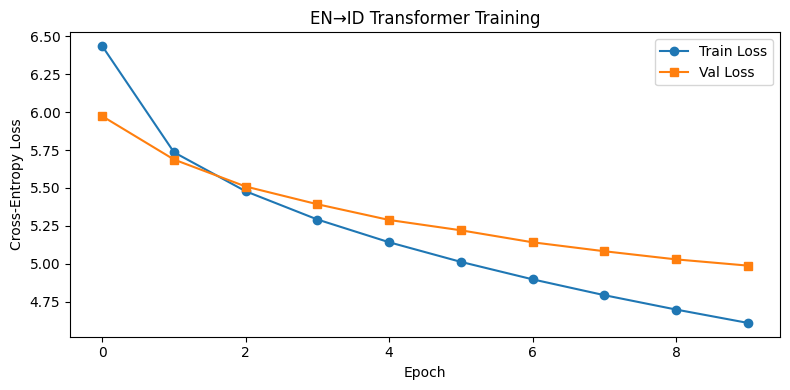

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses,   label="Val Loss",   marker='s')
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("EN→ID Transformer Training")
plt.legend()
plt.tight_layout()
plt.show()

# 8. Greedy Search

In [24]:
@torch.no_grad()
def translate(model, sentence: str, tokenizer, max_len=MAX_SEQ_LEN, device=device):
    model.eval()
    enc = tokenizer.encode(sentence)
    src_ids = torch.tensor([enc.ids], dtype=torch.long, device=device)  # (1, T)

    src_mask = model._make_src_mask(src_ids)
    enc_out  = model.encoder(src_ids, src_mask)

    tgt_ids = torch.tensor([[START_ID]], dtype=torch.long, device=device)

    for _ in range(max_len):
        tgt_mask = model._make_tgt_mask(tgt_ids)
        dec_out  = model.decoder(tgt_ids, enc_out, tgt_mask, src_mask)
        logits   = model.linear(dec_out)              # (1, t, V)
        next_id  = logits[:, -1, :].argmax(dim=-1)    # greedy
        tgt_ids  = torch.cat([tgt_ids, next_id.unsqueeze(0)], dim=1)
        if next_id.item() == END_ID:
            break

    pred_ids = tgt_ids[0].tolist()
    # strip special tokens
    pred_ids = [i for i in pred_ids if i not in (START_ID, END_ID, PAD_ID)]
    translation = tokenizer.decode(pred_ids, skip_special_tokens=True)
    return translation, src_ids, tgt_ids

# Inference

### Short Sentences

In [25]:
translation, _, _ = translate(model, "today is tuesday", tokenizer, device=device)

print(translation)
# Hari ini adalah selasa

Di hari ini adalah hari


In [26]:
out1, _, _ = translate(model, "Hello, how are you?", tokenizer)
print(out1)
# Halo, apa kabarmu?

Halo , bagaimana kau ?


In [27]:
out2, _, _ = translate(model, "I'm fine, thank you.", tokenizer)
print(out2)

# Aku baik, terimakasih

Aku baik - baik saja .


In [28]:
out3, _, _ = translate(model, "Thank you.", tokenizer)
print(out3)

# Terimakasih

Terima kasih .


In [29]:
out4, _, _ = translate(model, "I'm hungry.", tokenizer)
print(out4)

# Aku lapar

Aku lapar .


### Negation Sentences

In [30]:
out6, _, _ = translate(model, "i haven’t eaten yet", tokenizer)
print(out6)

# Aku belum makan

Aku belum pernah belum pernah


In [31]:
translation, _, _ = translate(model, "I have never been to this place before", tokenizer, device=device)

print(translation)

# Aku tak pernah ke tempat ini sebelumnya

Aku tak pernah pernah pernah melakukan ini sebelum ini


In [32]:
translation, _, _=translate(model, "She will never ever do that again", tokenizer, device=device)
print(translation)

# Dia tidak akan pernah melakukan itu lagi

Dia tidak pernah pernah melakukan itu lagi


In [33]:
out5, _, _ = translate(model, "I'm hungry because i haven’t eaten yet.", tokenizer)
print(out5)

# Aku lapar karena aku belum makan

Aku karena karena karena belum pernah belum pernah di sini .


In [34]:
translation, _, _=translate(model, "He doesn't know what he is doing", tokenizer, device=device)
print(translation)
# Dia tidak tahu apa yang dia lakukan

Dia tidak tahu apa yang dia lakukan


### Complex Grammar

In [35]:
translation, _, _=translate(model, "The more you learn, the more you grow", tokenizer, device=device)
print(translation)

# Makin banyak kau belajar, makin kau berkembang

Yang lebih banyak lagi , kau lebih baik


In [36]:
translation, _, _=translate(model, "The cat that the dog chased ran away", tokenizer, device=device)
print(translation)

# Kucing yang dikejar anjing itu melarikan diri

Yang Mulia itu menjadi seorang wanita yang telah di dalam neraka .


In [37]:
translation, _, _=translate(model, "Although it was raining heavily, we decided to go outside", tokenizer, device=device)
print(translation)

# Walaupun tadi hujan deras, kita memutuskan untuk pergi keluar

Meskipun itu adalah dia sangat baik , kita pergi ke rumah


In [38]:
translation, _, _=translate(model, "The student who studied hard for the exam finally passed", tokenizer, device=device)
print(translation)

# Murid yang belajar dengan baik untuk ujian akhirnya lulus

( Dan siapa yang telah mati ) yakni bagi orang - orang yang beriman ( untuk orang yang beriman ) yakni orang - orang yang beriman .


In [39]:
translation, _, _=translate(model, "I would have gone if you had asked me", tokenizer, device=device)
print(translation)

# Aku akan pergi jika kau mengajak aku

Aku akan pergi jika kau punya aku punya aku .


In [40]:
translation, _, _=translate(model, "She has been working here since 2020", tokenizer, device=device)
print(translation)

# Dia sudah bekerja disini sejak 2020

Dia telah bekerja di sini selama 20


### Compound Sentences

In [41]:
out, _,_ = translate(model, "I am hungry and tired", tokenizer, device=device)
print(out)
# Aku lapar dan lelah

Aku adalah orang dan lapar .


In [42]:
out, _, _ = translate(model, "She is smart but lazy", tokenizer, device=device)
print(out)
# Dia pintar tapi malas

Dia adalah seorang pria yang sangat penting .


In [43]:
out, _, _ = translate(model, "We can go now or wait until tomorrow", tokenizer, device=device)
print(out)
# Kita bisa pergi sekarang atau tunggu sampai besok

Kita bisa pergi sekarang atau tunggu besok besok


# 9. Attention Visualization

In [ ]:
def _get_tokens(ids, tokenizer):
    """Convert a list of token IDs to human-readable strings."""
    return [tokenizer.id_to_token(i) or str(i) for i in ids]

def show_attention_heatmap(
    attn_matrix,     # (T_q, T_k) numpy array
    row_labels,      # list of T_q strings (query side)
    col_labels,      # list of T_k strings (key side)
    title="Attention",
    figsize=(10, 8),
    cmap="Blues",
    cols = 2,
):
    """Generic attention heatmap — rows=queries, cols=keys."""
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(attn_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_xlabel("Key (attended to)", fontsize=11)
    ax.set_ylabel("Query (attending)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Encoder Self-Attention

In [ ]:
@torch.no_grad()
def show_encoder_self_attention(
    model, sentence, tokenizer,
    layer=0, head=0,
    device=device,
):
    """
    Show how English source tokens attend to each other in Encoder layer `layer`, head `head`.

    Each row is a query token (the word that is 'looking'),
    each column is a key token (the word being 'looked at').
    Brighter cells = stronger attention.
    """
    model.eval()
    enc   = tokenizer.encode(sentence)
    ids   = enc.ids
    # strip padding
    nonpad = [i for i, x in enumerate(ids) if x != PAD_ID]
    if not nonpad:
        print("Empty sequence."); return
    end   = nonpad[-1] + 1
    ids_t = torch.tensor([ids], dtype=torch.long, device=device)

    src_mask = model._make_src_mask(ids_t)
    x        = model.encoder.embedding(ids_t)

    attns = []
    for lyr in model.encoder.layers:
        x, attn = lyr(x, src_mask, return_attention=True)
        attns.append(attn)   # (1, H, T, T)

    attn_np = attns[layer][0, head, :end, :end].cpu().numpy()  # (T, T)
    labels  = _get_tokens(ids[:end], tokenizer)

    show_attention_heatmap(
        attn_np, labels, labels,
        title=f"Encoder Self-Attention  |  Layer {layer}  Head {head}\n\"{sentence}\"",
        cmap="YlOrRd",
    )

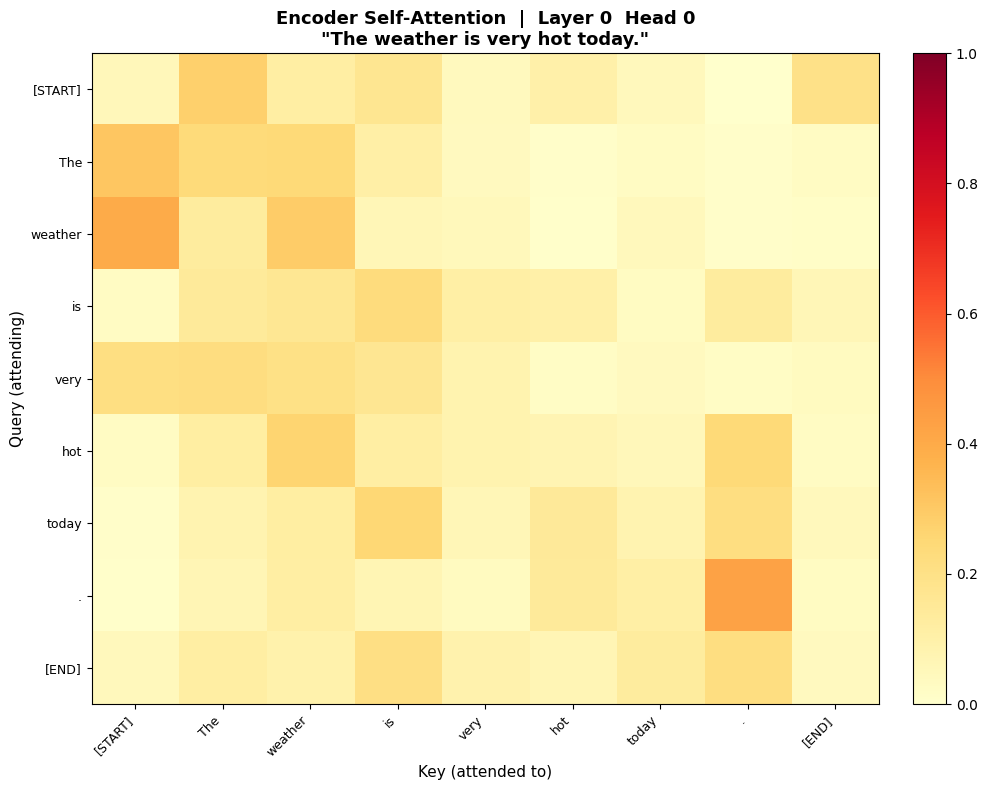

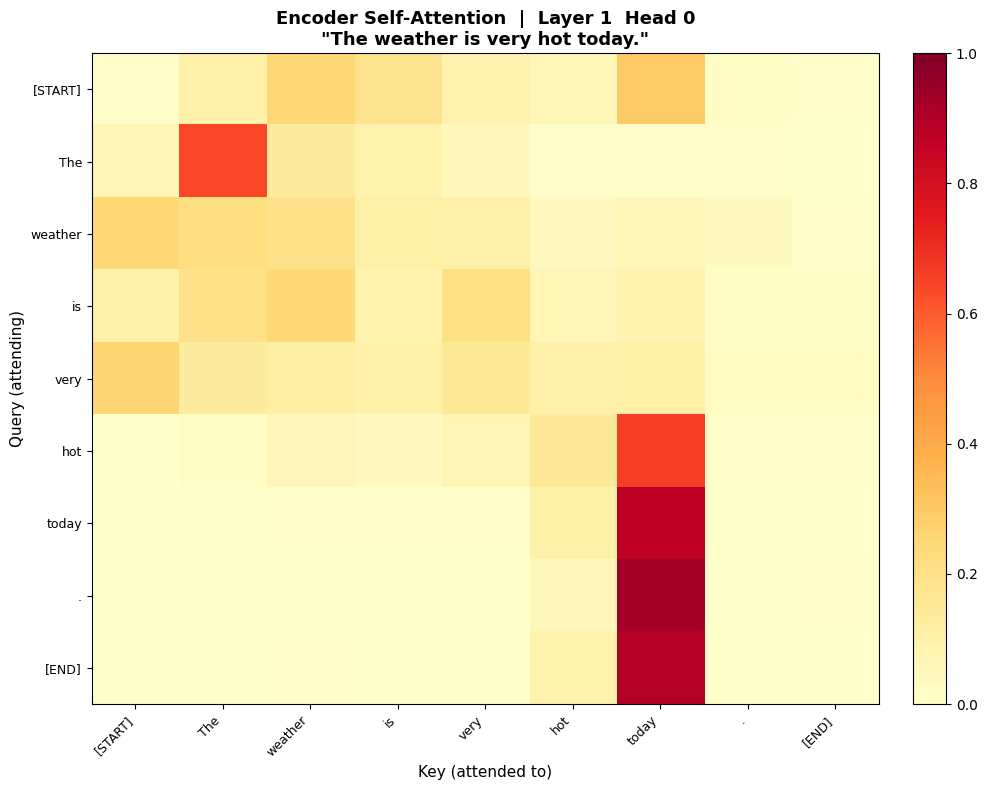

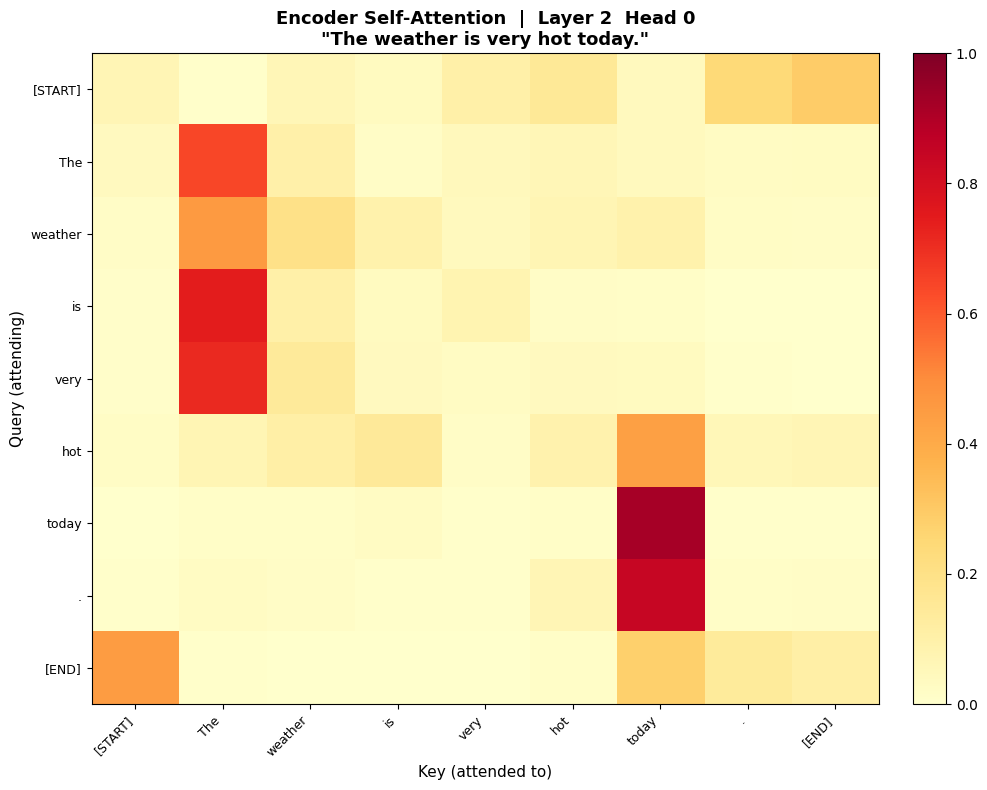

In [ ]:
test_sentence = "The weather is very hot today."

# Try different layers (0 to NUM_LAYERS-1) and heads (0 to NUM_HEADS-1)
for layer_idx in range(NUM_LAYERS):
    show_encoder_self_attention(model, test_sentence, tokenizer, layer=layer_idx, head=0)

## Decoder Self-Attention (causal)

In [ ]:
@torch.no_grad()
def show_decoder_self_attention(
    model, sentence, tokenizer,
    layer=0, head=0,
    device=device,
):
    """
    Show causal self-attention inside the Decoder:
    how each generated Indonesian token attends to the tokens before it.
    """
    model.eval()
    _, src_ids, tgt_ids = translate(model, sentence, tokenizer, device=device)

    src_mask = model._make_src_mask(src_ids)
    tgt_mask = model._make_tgt_mask(tgt_ids)
    enc_out  = model.encoder(src_ids, src_mask)

    x = model.decoder.embedding(tgt_ids)
    self_attns, cross_attns = [], []
    for lyr in model.decoder.layers:
        x, sa, ca = lyr(x, enc_out, tgt_mask, src_mask, return_attention=True)
        self_attns.append(sa)
        cross_attns.append(ca)

    T_tgt  = tgt_ids.size(1)
    labels = _get_tokens(tgt_ids[0].tolist(), tokenizer)
    attn_np = self_attns[layer][0, head, :T_tgt, :T_tgt].cpu().numpy()

    show_attention_heatmap(
        attn_np, labels, labels,
        title=f"Decoder Self-Attention (causal)  |  Layer {layer}  Head {head}\nEN: \"{sentence}\"",
        cmap="Purples",
    )


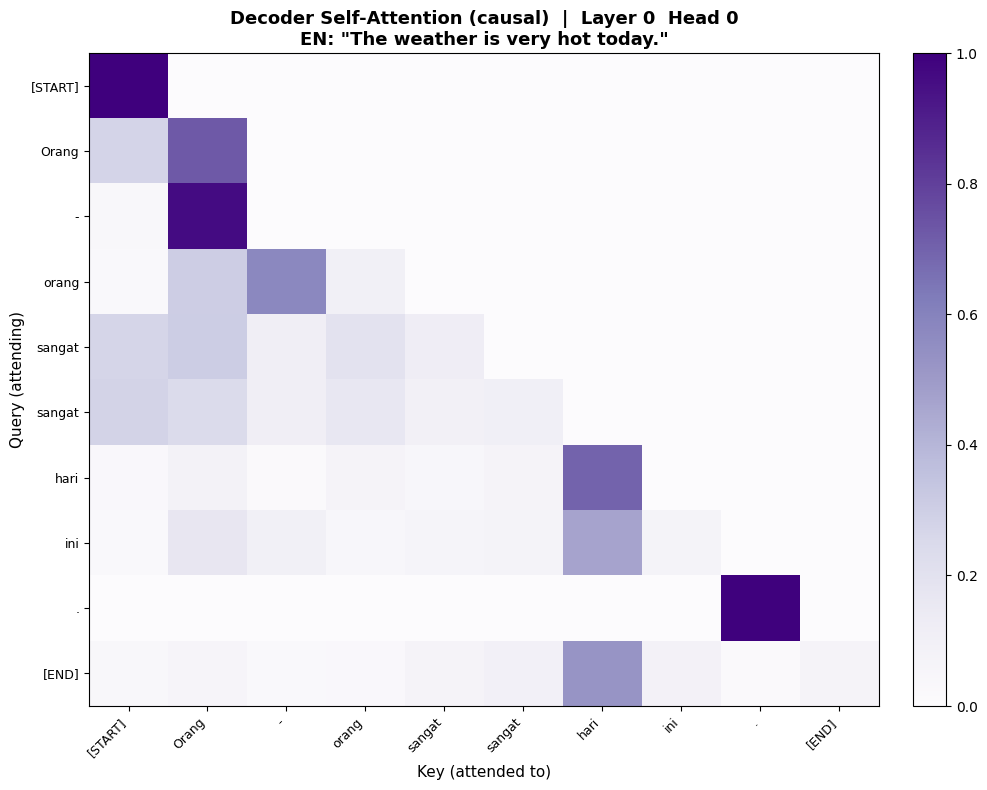

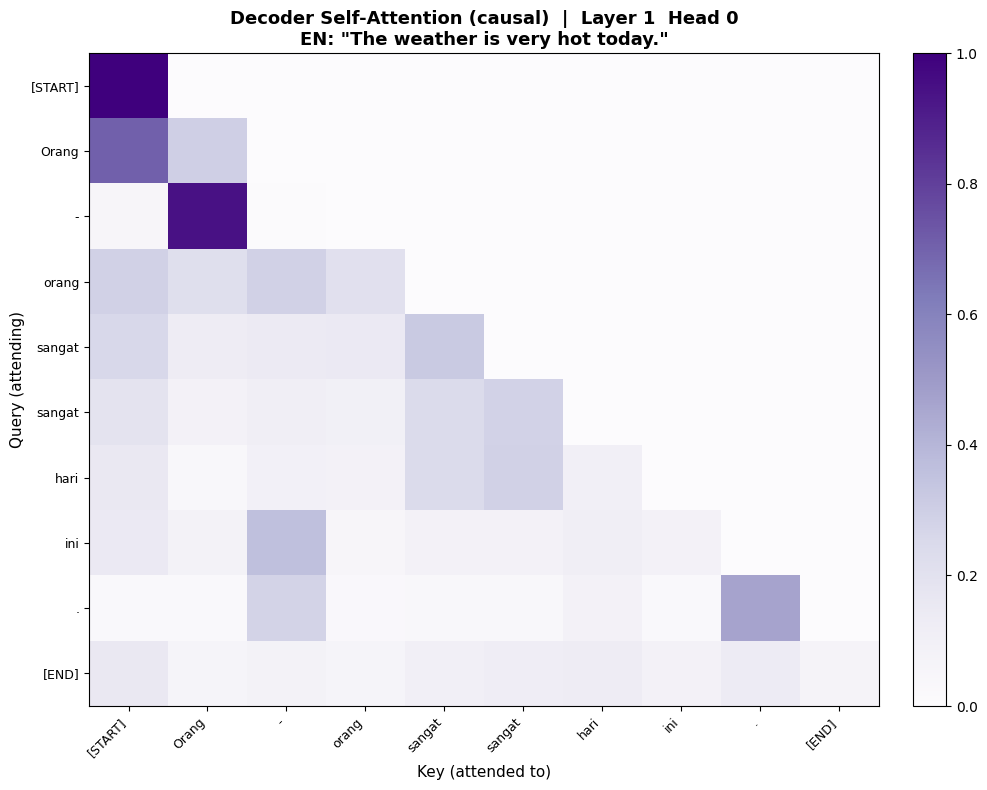

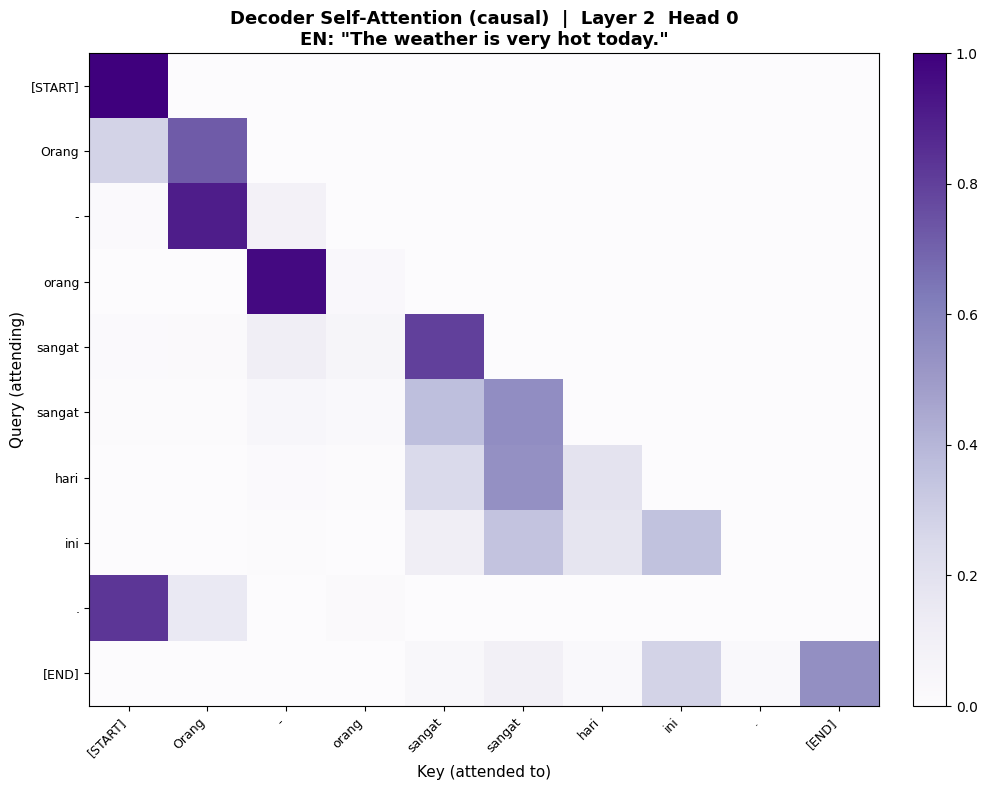

In [ ]:
for layer_idx in range(NUM_LAYERS):
    show_decoder_self_attention(model, test_sentence, tokenizer, layer=layer_idx, head=0)

## Cross-Attention

In [ ]:
@torch.no_grad()
def show_cross_attention(
    model, sentence, tokenizer,
    layer=0, head=0,
    device=device,
):
    """
    Show encoder-decoder (cross) attention:
    for each Indonesian output token (rows), which English input tokens it looked at (columns).
    This is the core alignment — the 'translation map'.
    """
    model.eval()
    translation, src_ids, tgt_ids = translate(model, sentence, tokenizer, device=device)

    src_mask = model._make_src_mask(src_ids)
    tgt_mask = model._make_tgt_mask(tgt_ids)
    enc_out  = model.encoder(src_ids, src_mask)

    x = model.decoder.embedding(tgt_ids)
    cross_attns = []
    for lyr in model.decoder.layers:
        x, sa, ca = lyr(x, enc_out, tgt_mask, src_mask, return_attention=True)
        cross_attns.append(ca)

    # trim padding from source
    src_list = src_ids[0].tolist()
    nonpad   = [i for i, x in enumerate(src_list) if x != PAD_ID]
    T_src    = nonpad[-1] + 1 if nonpad else src_ids.size(1)
    T_tgt    = tgt_ids.size(1)

    src_labels = _get_tokens(src_list[:T_src], tokenizer)
    tgt_labels = _get_tokens(tgt_ids[0].tolist()[:T_tgt], tokenizer)

    attn_np = cross_attns[layer][0, head, :T_tgt, :T_src].cpu().numpy()

    show_attention_heatmap(
        attn_np, tgt_labels, src_labels,
        title=(
            f"Cross-Attention (EN→ID Alignment)  |  Layer {layer}  Head {head}\n"
            f"EN: \"{sentence}\"\nID: \"{translation}\""
        ),
        figsize=(12, 7),
        cmap="Greens",
    )


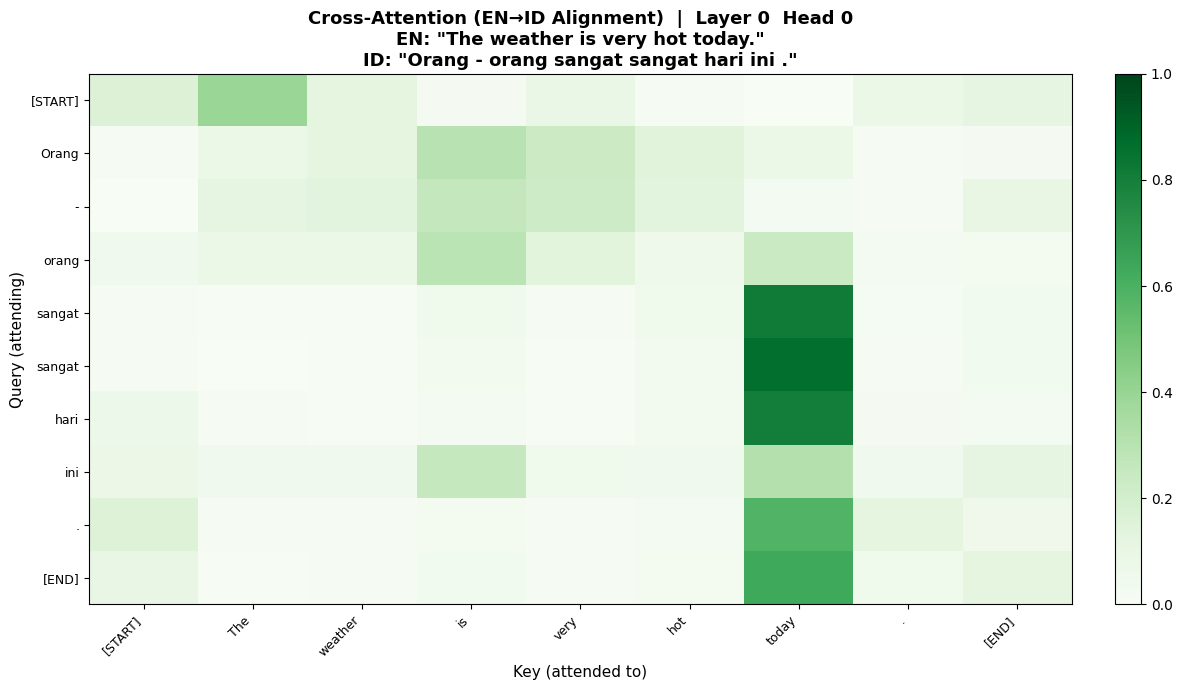

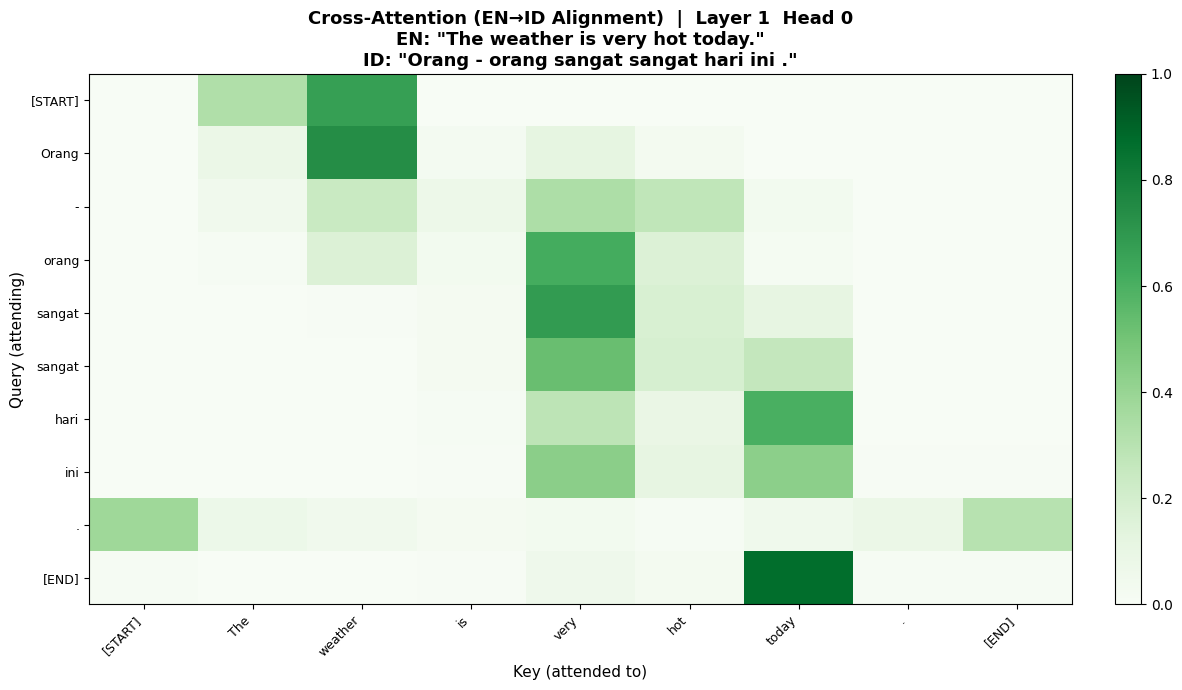

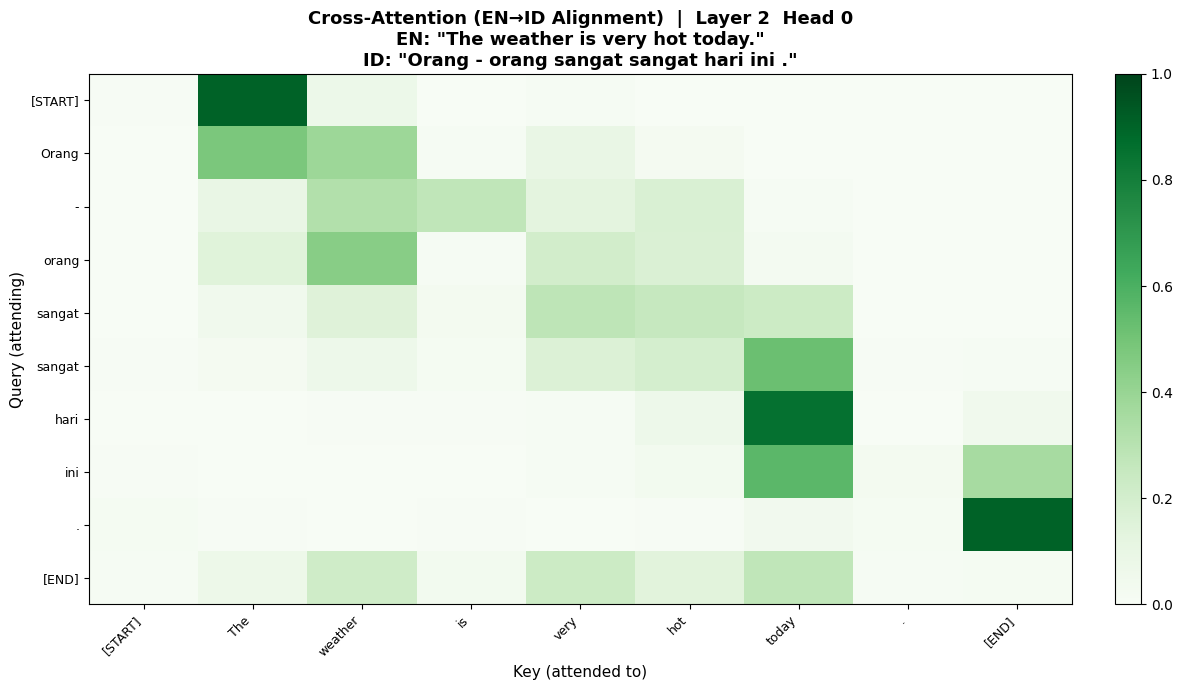

In [ ]:
for layer_idx in range(NUM_LAYERS):
    show_cross_attention(model, test_sentence, tokenizer, layer=layer_idx, head=0)

## All Heads — Cross-Attention Grid

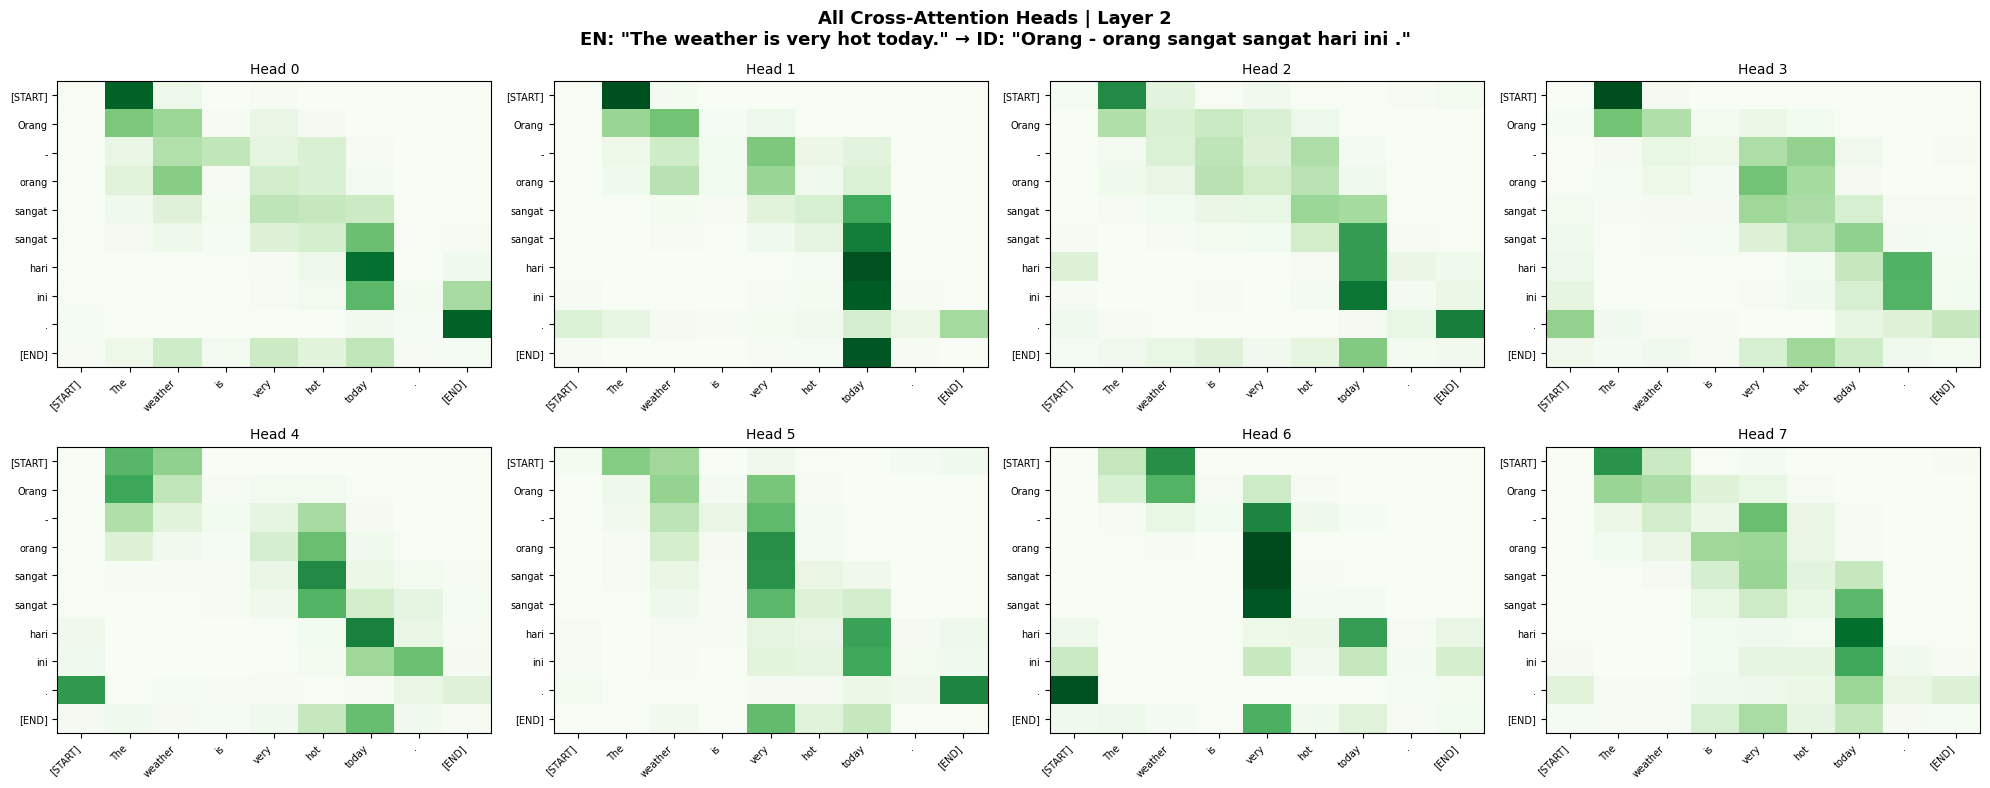

In [ ]:
@torch.no_grad()
def show_all_heads_cross_attention(model, sentence, tokenizer, layer=0, device=device):
    """Plot all NUM_HEADS cross-attention heads for a given layer in a grid."""
    model.eval()
    translation, src_ids, tgt_ids = translate(model, sentence, tokenizer, device=device)

    src_mask = model._make_src_mask(src_ids)
    tgt_mask = model._make_tgt_mask(tgt_ids)
    enc_out  = model.encoder(src_ids, src_mask)

    x = model.decoder.embedding(tgt_ids)
    cross_attns = []
    for lyr in model.decoder.layers:
        x, sa, ca = lyr(x, enc_out, tgt_mask, src_mask, return_attention=True)
        cross_attns.append(ca)

    src_list = src_ids[0].tolist()
    nonpad   = [i for i, v in enumerate(src_list) if v != PAD_ID]
    T_src    = nonpad[-1] + 1 if nonpad else src_ids.size(1)
    T_tgt    = tgt_ids.size(1)
    src_labels = _get_tokens(src_list[:T_src], tokenizer)
    tgt_labels = _get_tokens(tgt_ids[0].tolist()[:T_tgt], tokenizer)

    n_heads = cross_attns[layer].shape[1]
    cols    = 4
    rows    = math.ceil(n_heads / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten()

    for h in range(n_heads):
        attn_np = cross_attns[layer][0, h, :T_tgt, :T_src].cpu().numpy()
        ax = axes[h]
        im = ax.imshow(attn_np, cmap="Greens", aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(T_src))
        ax.set_xticklabels(src_labels, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(T_tgt))
        ax.set_yticklabels(tgt_labels, fontsize=7)
        ax.set_title(f"Head {h}", fontsize=10)

    for h in range(n_heads, len(axes)):
        axes[h].axis('off')

    fig.suptitle(
        f"All Cross-Attention Heads | Layer {layer}\nEN: \"{sentence}\" → ID: \"{translation}\"",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


show_all_heads_cross_attention(model, test_sentence, tokenizer, layer=NUM_LAYERS - 1)

ENCODER SELF-ATTENTION


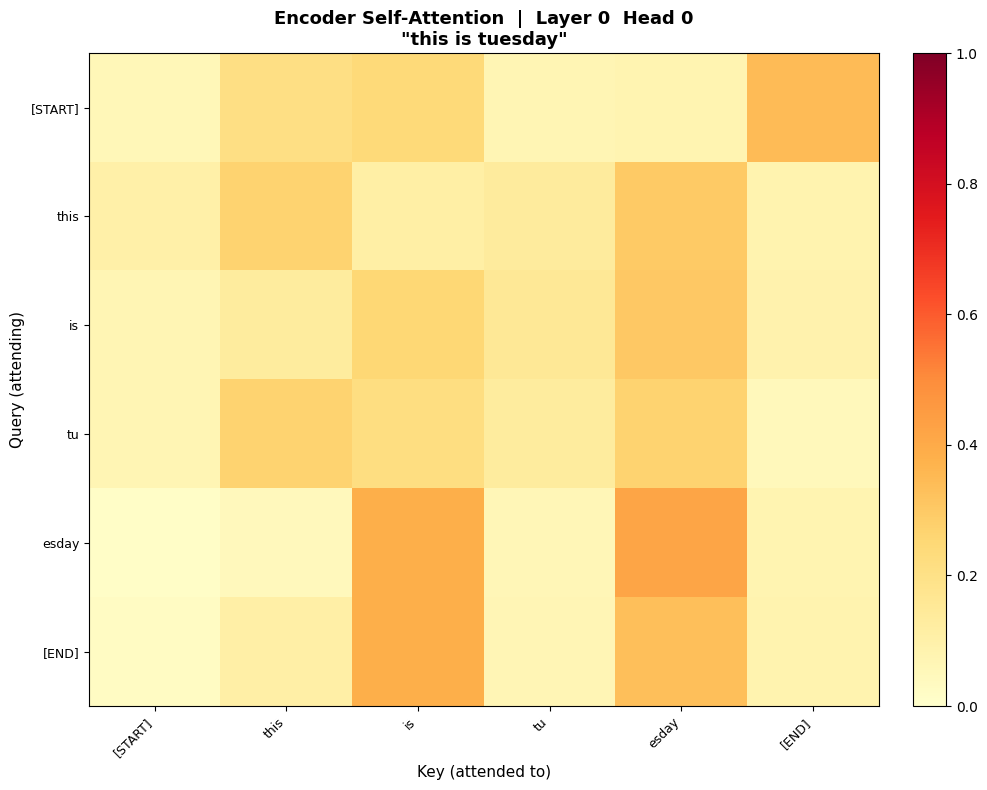

DECODER SELF-ATTENTION


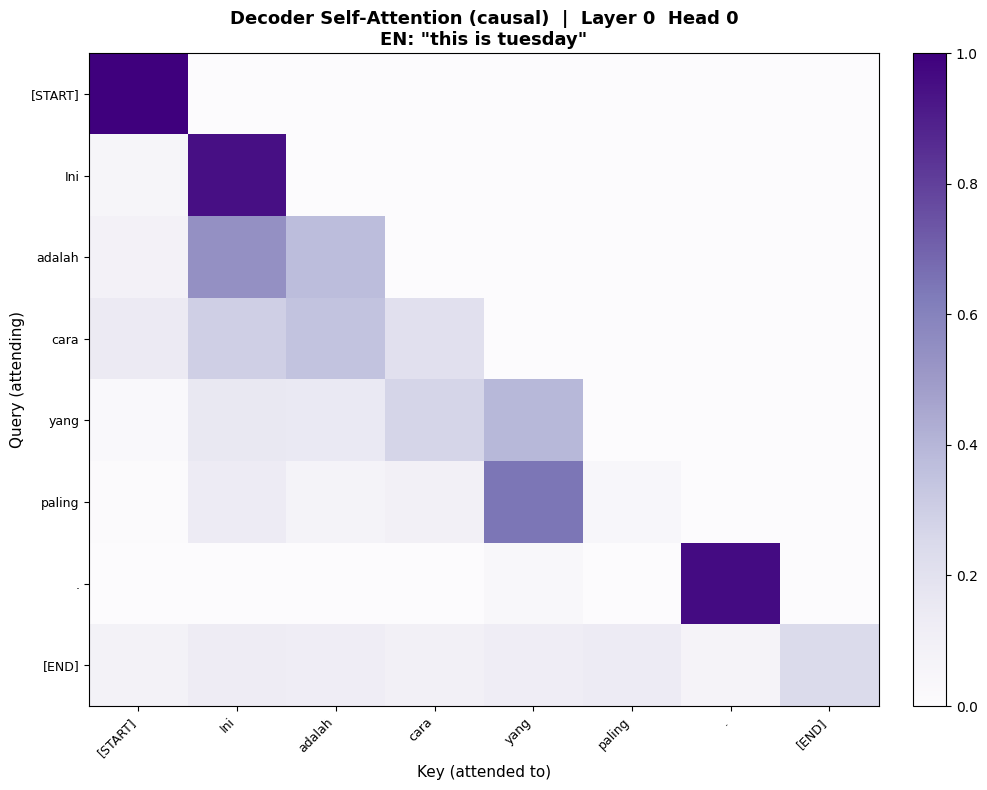

CROSS-ATTENTION (ALIGNMENT)


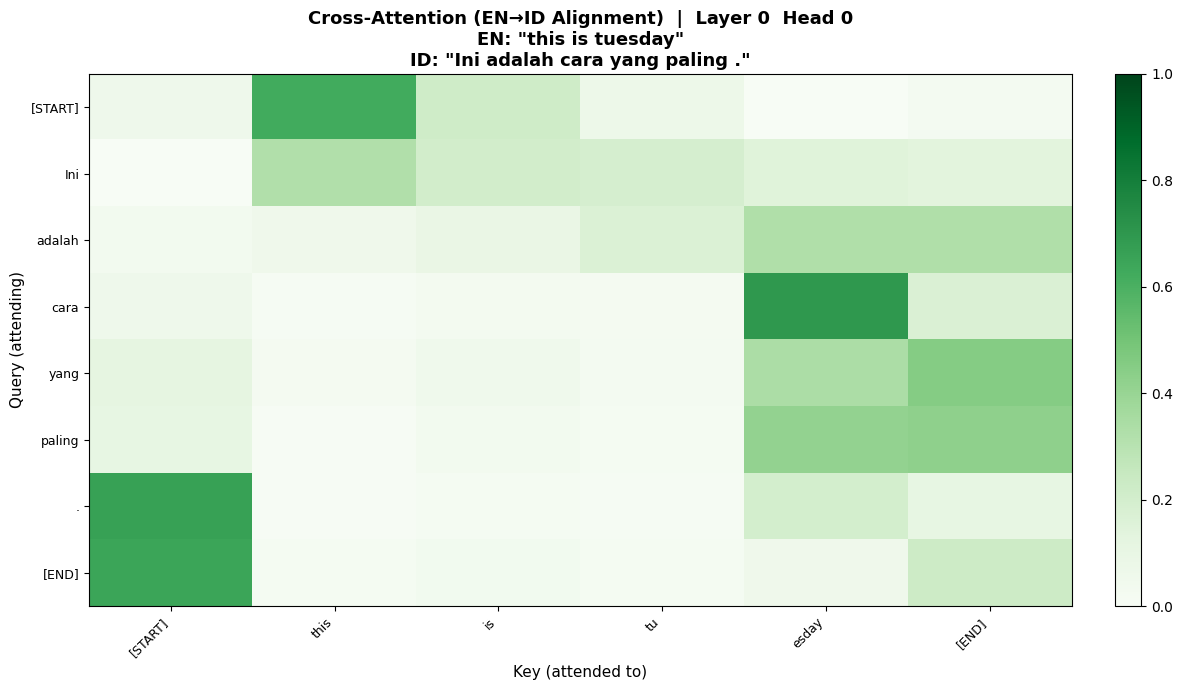

In [ ]:
SENTENCE = "this is tuesday"
LAYER    = 0
HEAD     = 0

print("=" * 60)
print("ENCODER SELF-ATTENTION")
show_encoder_self_attention(model, SENTENCE, tokenizer, layer=LAYER, head=HEAD)

print("=" * 60)
print("DECODER SELF-ATTENTION")
show_decoder_self_attention(model, SENTENCE, tokenizer, layer=LAYER, head=HEAD)

print("=" * 60)
print("CROSS-ATTENTION (ALIGNMENT)")
show_cross_attention(model, SENTENCE, tokenizer, layer=LAYER, head=HEAD)

# 10. Save Model

In [ ]:
torch.save(model.state_dict(), "en_id_transformer.pt")
tokenizer.save("bpe_tokenizer.json")
print("Model and tokenizer saved.")


Model and tokenizer saved.


# 11. Load Model

In [18]:
tokenizer = Tokenizer.from_file("bpe_tokenizer.json")

In [19]:
ACTUAL_VOCAB_SIZE = tokenizer.get_vocab_size()
MAX_SEQ_LEN = 50

In [20]:
START_TOKEN = "[START]"
END_TOKEN   = "[END]"
PAD_TOKEN   = "[PAD]"
UNK_TOKEN   = "[UNK]"
tokenizer.enable_padding(
    pad_id=tokenizer.token_to_id(PAD_TOKEN),
    pad_token=PAD_TOKEN,
    length=MAX_SEQ_LEN,
)
tokenizer.enable_truncation(max_length=MAX_SEQ_LEN)

ACTUAL_VOCAB_SIZE = tokenizer.get_vocab_size()
PAD_ID   = tokenizer.token_to_id(PAD_TOKEN)
START_ID = tokenizer.token_to_id(START_TOKEN)
END_ID   = tokenizer.token_to_id(END_TOKEN)


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/transformer')  # path to the folder containing transformer/

from transformer import Transformer

In [21]:
# hyperparameters
D_MODEL     = 256    # embedding dimension
FFN_HIDDEN  = 512    # feed-forward inner dimension
NUM_HEADS   = 8      # attention heads (D_MODEL must be divisible by this)
NUM_LAYERS  = 3      # encoder & decoder depth
DROP_PROB   = 0.1
NUM_EPOCHS  = 10
LR          = 1e-4

model = Transformer(
    vocab_size  = ACTUAL_VOCAB_SIZE,
    d_model     = D_MODEL,
    ffn_hidden  = FFN_HIDDEN,
    num_heads   = NUM_HEADS,
    drop_prob   = DROP_PROB,
    num_layers  = NUM_LAYERS,
    max_seq_len = MAX_SEQ_LEN,
    pad_id      = PAD_ID,
).to(device)

In [22]:
# Load weight
model.load_state_dict(torch.load("en_id_transformer.pt"))

<All keys matched successfully>

In [23]:
model.eval()

Transformer(
  (encoder): Encoder(
    (embedding): SentenceEmbedding(
      (embedding): Embedding(16000, 256, padding_idx=0)
      (position_encoder): PositionalEncoding()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (attention): MultiHeadAttention(
          (qkv_layer): Linear(in_features=256, out_features=768, bias=True)
          (linear_layer): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNormalization()
        (dropout1): Dropout(p=0.1, inplace=False)
        (ffn): PositionwiseFeedForward(
          (net): Sequential(
            (0): Linear(in_features=256, out_features=512, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=512, out_features=256, bias=True)
          )
        )
        (norm2): LayerNormalization()
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): D